In [1]:
# Data Loading & Data Handling
import pandas as pd
import numpy as np
# Data Visualization / EDA
import matplotlib.pyplot as plt
import seaborn as sns
# Train-Test Split
from sklearn.model_selection import train_test_split
# Data Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
# Feature Importance
# model.feature_importances_
# model.coef_
# Model Saving
import joblib
# Streamlit Deployment
import streamlit as st

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load the Dataset

In [2]:
df = pd.read_csv("Dataset.csv")

# 3. EDA

## 3.1 Basic dataset check

In [3]:
df.shape

(10000, 19)

In [4]:
df.head()

,CustomerID,Age,Gender,State,Operator,SIMTenureMonths,RechargeAmount,RechargeFrequencyDays,DataUsageGB,CallMinutes,SMSUsage,PlanType,NetworkComplaints,DroppedCalls,LateRechargeDays,CustomerSupportCalls,SatisfactionScore,PortRequest,Churn
0,CUST00001,28,Male,Delhi,Vi,9,149,21,36.84,418,24,Prepaid,3,6,23,3,2,No,No
1,CUST00002,32,Female,Karnataka,Jio,107,99,28,22.42,910,49,Prepaid,1,6,0,4,3,No,No
2,CUST00003,33,Female,Gujarat,Jio,35,799,30,26.98,302,78,Postpaid,1,12,7,1,4,No,No
3,CUST00004,33,Female,Rajasthan,Airtel,90,299,45,25.53,759,51,Prepaid,0,12,0,0,5,No,No
4,CUST00005,27,Male,Tamil Nadu,Airtel,6,299,35,10.86,944,26,Prepaid,0,7,3,0,4,No,No


In [5]:
df.tail()

,CustomerID,Age,Gender,State,Operator,SIMTenureMonths,RechargeAmount,RechargeFrequencyDays,DataUsageGB,CallMinutes,SMSUsage,PlanType,NetworkComplaints,DroppedCalls,LateRechargeDays,CustomerSupportCalls,SatisfactionScore,PortRequest,Churn
9995,CUST09996,28,Female,Telangana,BSNL,30,699,30,36.64,644,63,Postpaid,1,13,1,3,4,No,No
9996,CUST09997,25,Female,Maharashtra,Vi,43,1199,30,21.85,925,25,Postpaid,0,6,0,0,5,No,No
9997,CUST09998,41,Female,Karnataka,Jio,3,599,14,40.79,885,41,Prepaid,0,2,3,2,5,No,No
9998,CUST09999,29,Male,Tamil Nadu,Airtel,16,199,28,2.73,123,6,Prepaid,0,0,9,0,5,No,Yes
9999,CUST10000,31,Male,Gujarat,Jio,7,299,28,11.49,141,44,Prepaid,7,40,0,5,1,Yes,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             10000 non-null  object 
 1   Age                    10000 non-null  int64  
 2   Gender                 10000 non-null  object 
 3   State                  10000 non-null  object 
 4   Operator               10000 non-null  object 
 5   SIMTenureMonths        10000 non-null  int64  
 6   RechargeAmount         10000 non-null  int64  
 7   RechargeFrequencyDays  10000 non-null  int64  
 8   DataUsageGB            10000 non-null  float64
 9   CallMinutes            10000 non-null  int64  
 10  SMSUsage               10000 non-null  int64  
 11  PlanType               10000 non-null  object 
 12  NetworkComplaints      10000 non-null  int64  
 13  DroppedCalls           10000 non-null  int64  
 14  LateRechargeDays       10000 non-null  int64  
 15  Cus

In [7]:
df.describe()

,Age,SIMTenureMonths,RechargeAmount,RechargeFrequencyDays,DataUsageGB,CallMinutes,SMSUsage,NetworkComplaints,DroppedCalls,LateRechargeDays,CustomerSupportCalls,SatisfactionScore
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,35.332100,41.413000,468.861000,32.569300,25.336520,619.857500,56.400400,2.023300,10.672300,5.155800,1.817500,3.651000
std,11.192271,32.536907,396.124503,11.996832,14.658261,392.586131,43.801547,2.209128,8.619185,6.172871,1.414918,1.221617
min,18.000000,1.000000,99.000000,14.000000,0.500000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,27.000000,15.000000,239.000000,28.000000,14.667500,332.000000,24.000000,0.000000,4.000000,1.000000,1.000000,3.000000
50%,35.000000,34.000000,399.000000,28.000000,22.660000,538.000000,46.000000,1.000000,9.000000,3.000000,2.000000,4.000000
75%,43.000000,60.000000,499.000000,35.000000,32.982500,820.000000,77.000000,3.000000,15.000000,7.000000,3.000000,5.000000
max,70.000000,120.000000,2999.000000,90.000000,100.000000,3000.000000,350.000000,10.000000,50.000000,30.000000,8.000000,5.000000


## 3.2 Target Variable Analysis

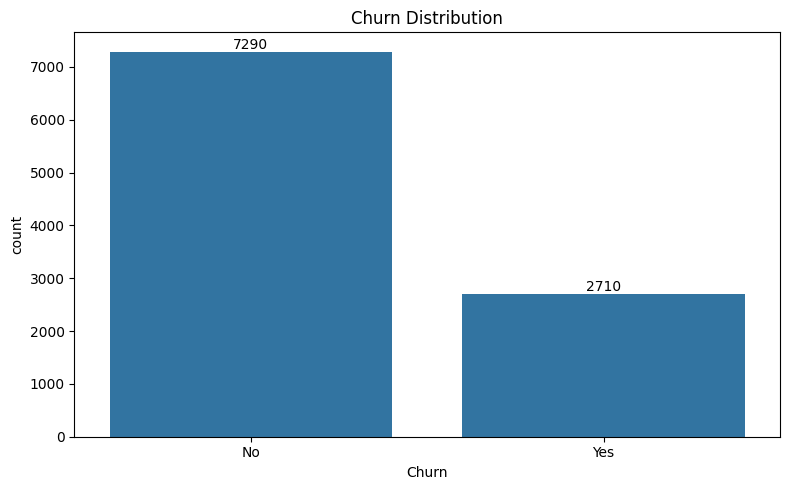

In [8]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Churn', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churn Distribution")
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.3 Categorical Feature Analysis

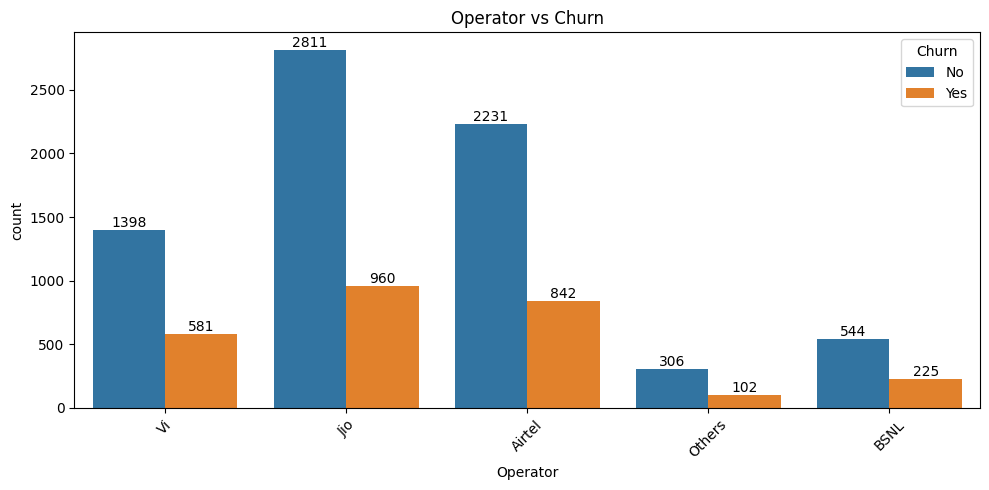

In [9]:
plt.figure(figsize=(10,5))
ax = sns.countplot(x='Operator', hue='Churn', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Operator vs Churn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('operator_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

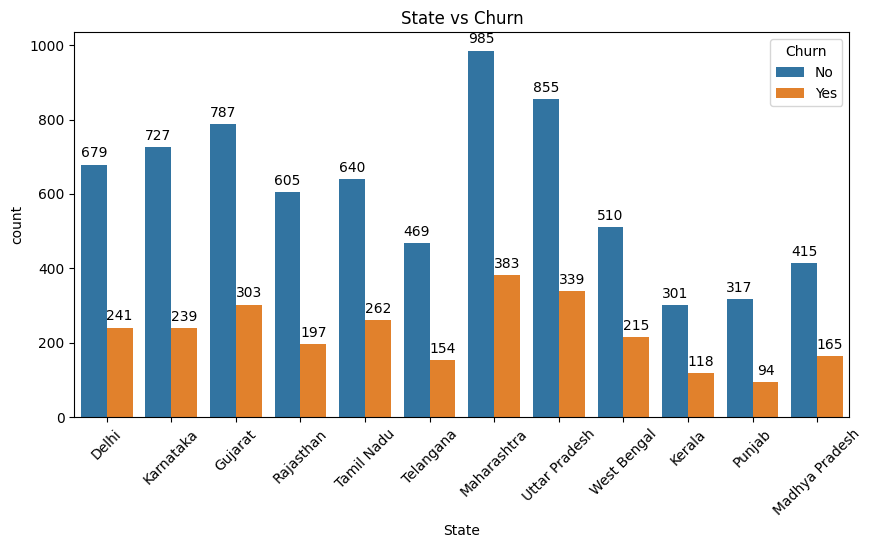

In [10]:
# State vs Churn with data labels
plt.figure(figsize=(10,5))
ax = sns.countplot(x='State', hue='Churn', data=df)

# Add data labels on top of bars
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.xticks(rotation=45)
plt.title("State vs Churn")
plt.savefig('state_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

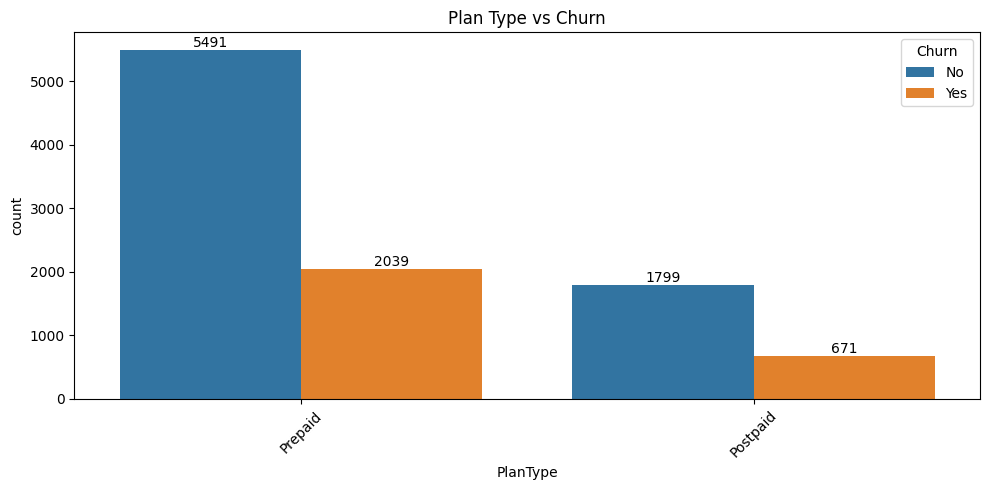

In [11]:
plt.figure(figsize=(10,5))
ax = sns.countplot(x='PlanType', hue='Churn', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Plan Type vs Churn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plantype_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

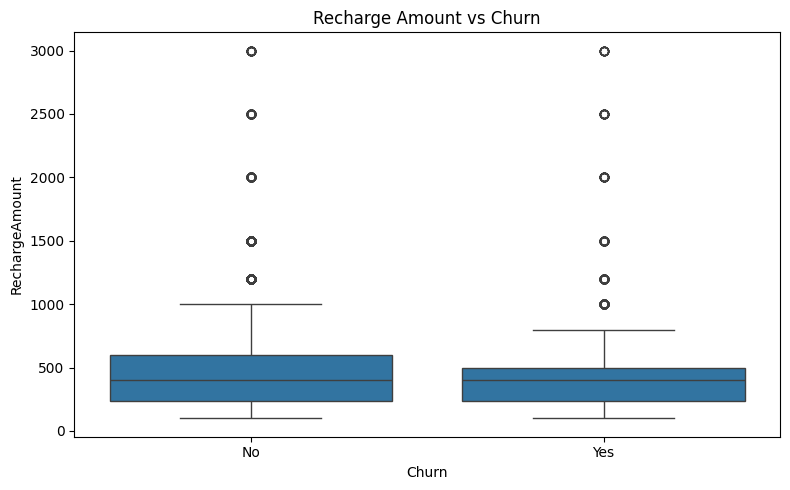

In [12]:
# Numerical Feature Analysis
# # Recharge Amount
plt.figure(figsize=(8,5))
ax = sns.boxplot(x='Churn', y='RechargeAmount', data=df)
plt.title("Recharge Amount vs Churn")
plt.tight_layout()
plt.savefig('rechargeamount_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

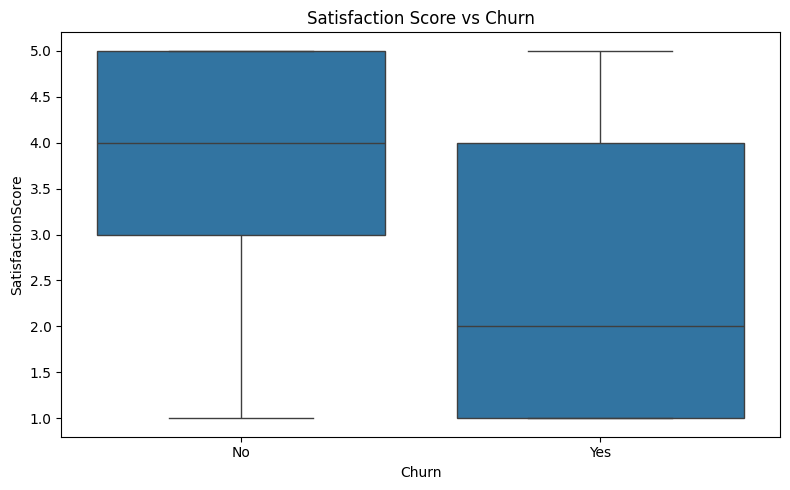

In [13]:
# # Satisfaction Score
plt.figure(figsize=(8,5))
ax = sns.boxplot(x='Churn', y='SatisfactionScore', data=df)
plt.title("Satisfaction Score vs Churn")
plt.tight_layout()
plt.savefig('satisfactionscore_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

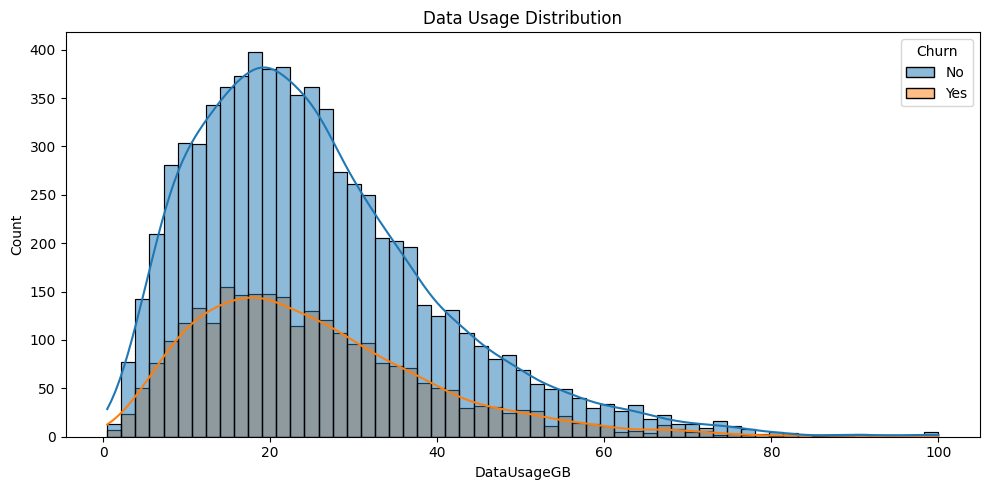

In [14]:
# # Data Usage
plt.figure(figsize=(10,5))
ax = sns.histplot(data=df, x='DataUsageGB', hue='Churn', kde=True)
plt.title("Data Usage Distribution")
plt.tight_layout()
plt.savefig('datausage_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

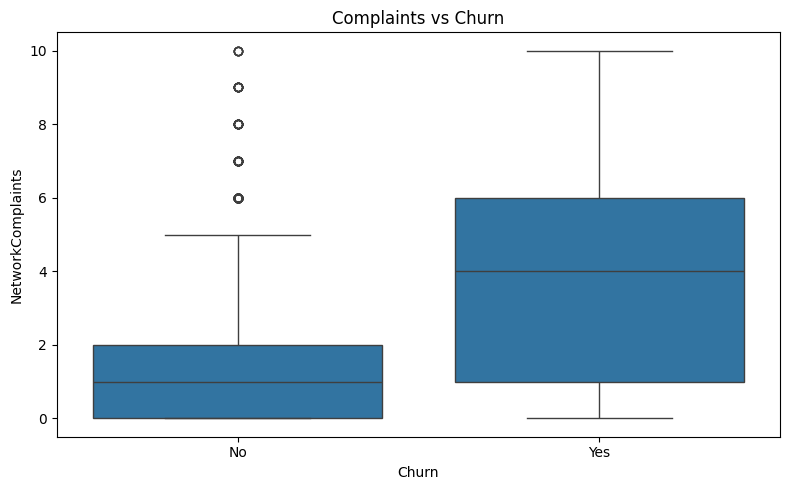

In [15]:
# High Value Business Charts
# # Complaints vs Churn
plt.figure(figsize=(8,5))
ax = sns.boxplot(x='Churn', y='NetworkComplaints', data=df)
plt.title("Complaints vs Churn")
plt.tight_layout()
plt.savefig('complaints_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

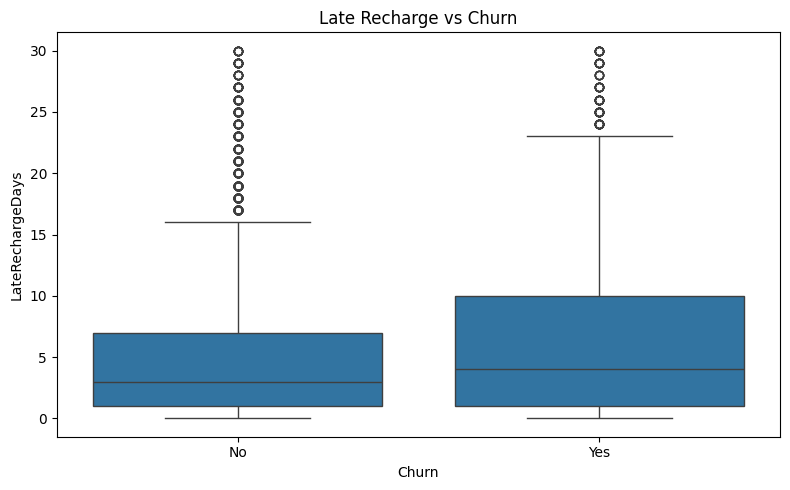

In [16]:
# # Late Recharge vs Churn
plt.figure(figsize=(8,5))
ax = sns.boxplot(x='Churn', y='LateRechargeDays', data=df)
plt.title("Late Recharge vs Churn")
plt.tight_layout()
plt.savefig('laterecharge_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

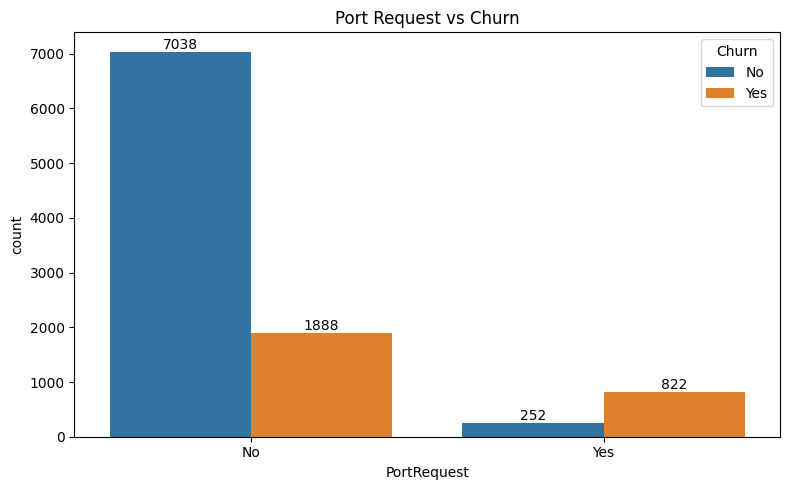

In [17]:
# # Port Request vs Churn
plt.figure(figsize=(8,5))
ax = sns.countplot(x='PortRequest', hue='Churn', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Port Request vs Churn")
plt.tight_layout()
plt.savefig('portrequest_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Label encoding / Data preprocessing

In [18]:
df_model = df.copy()

le = LabelEncoder()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

# 5. Train and Test split

In [19]:
X = df_model.drop(['CustomerID','Churn'], axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 6. Model training and Model evaluation

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print("="*80)
    print(name)
    print("Accuracy:", round(acc*100,2), "%")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))

C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 83.6 %
[[1394   87]
 [ 241  278]]
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1481
           1       0.76      0.54      0.63       519

    accuracy                           0.84      2000
   macro avg       0.81      0.74      0.76      2000
weighted avg       0.83      0.84      0.83      2000

Decision Tree
Accuracy: 74.05 %
[[1183  298]
 [ 221  298]]
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1481
           1       0.50      0.57      0.53       519

    accuracy                           0.74      2000
   macro avg       0.67      0.69      0.68      2000
weighted avg       0.75      0.74      0.75      2000

Random Forest
Accuracy: 83.45 %
[[1384   97]
 [ 234  285]]
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1481
           1       0.75      0.55      0.63       519



C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:47:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
Accuracy: 82.6 %
[[1362  119]
 [ 229  290]]
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1481
           1       0.71      0.56      0.62       519

    accuracy                           0.83      2000
   macro avg       0.78      0.74      0.76      2000
weighted avg       0.82      0.83      0.82      2000



# 7. Finalizing the Model

In [21]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8225
[[1309  172]
 [ 183  336]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1481
           1       0.66      0.65      0.65       519

    accuracy                           0.82      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.82      0.82      0.82      2000



# 8. Feature Importance Analysis

In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(10))

                 Feature  Importance
15     SatisfactionScore    0.221395
11     NetworkComplaints    0.142829
16           PortRequest    0.113638
14  CustomerSupportCalls    0.107422
12          DroppedCalls    0.084353
4        SIMTenureMonths    0.064181
13      LateRechargeDays    0.046193
7            DataUsageGB    0.037758
8            CallMinutes    0.035712
9               SMSUsage    0.032747


# 9. Save the Model

In [23]:
# Save trained model
joblib.dump(rf, "churn_model.pkl")

# Save feature column names
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("Model saved successfully")

Model saved successfully
